In [2]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint



In [3]:
# -------------------------------
# PATHS
# -------------------------------
train_dir = r"D:\Chilli final dataset\augtrain"
val_dir   = r"D:\Chilli final dataset\val"
test_dir = r"D:\Chilli final dataset\test"

IMG_SIZE = 224
BATCH_SIZE = 32

# MixUp / CutMix parameters
MIXUP_ALPHA = 0.2
CUTMIX_ALPHA = 1.0
MIX_PROB = 0.5   # 50% MixUp, 50% CutMix

# -------------------------------
# 🔥 DATA AUGMENTATION
# -------------------------------
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    brightness_range=[0.7, 1.3],
    shear_range=0.15,
    horizontal_flip=True,
    fill_mode='nearest'
)



val_datagen = ImageDataGenerator(rescale=1./255)

train_gen_base = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_gen = val_datagen.flow_from_directory(
    val_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_datagen = ImageDataGenerator(rescale=1./255)

test_gen = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False   # IMPORTANT for metrics
)

num_classes = train_gen_base.num_classes



Found 24000 images belonging to 3 classes.
Found 2207 images belonging to 3 classes.
Found 2207 images belonging to 3 classes.


In [4]:
# -------------------------------
# 🔥 MIXUP FUNCTION
# -------------------------------
def mixup(x1, y1, x2, y2, alpha=0.2):
    lam = np.random.beta(alpha, alpha)
    x = lam * x1 + (1 - lam) * x2
    y = lam * y1 + (1 - lam) * y2
    return x, y

# -------------------------------
# 🔥 CUTMIX FUNCTION
# -------------------------------
def cutmix(x1, y1, x2, y2, alpha=1.0):
    lam = np.random.beta(alpha, alpha)

    batch_size, h, w, c = x1.shape

    # Random box
    cx = np.random.randint(w)
    cy = np.random.randint(h)

    cut_w = int(w * np.sqrt(1 - lam))
    cut_h = int(h * np.sqrt(1 - lam))

    x1_copy = np.copy(x1)

    x1_copy[:, 
            max(cy - cut_h // 2, 0):min(cy + cut_h // 2, h),
            max(cx - cut_w // 2, 0):min(cx + cut_w // 2, w), :] = \
    x2[:, 
        max(cy - cut_h // 2, 0):min(cy + cut_h // 2, h),
        max(cx - cut_w // 2, 0):min(cx + cut_w // 2, w), :]

    lam_adjusted = 1 - (cut_w * cut_h) / (w * h)
    y = lam_adjusted * y1 + (1 - lam_adjusted) * y2

    return x1_copy, y

# -------------------------------
# 🔥 COMBINED GENERATOR
# -------------------------------
def mix_generator(generator):
    while True:
        x1, y1 = next(generator)
        x2, y2 = next(generator)

        if np.random.rand() < MIX_PROB:
            x, y = mixup(x1, y1, x2, y2, MIXUP_ALPHA)
        else:
            x, y = cutmix(x1, y1, x2, y2, CUTMIX_ALPHA)

        yield x, y

train_gen = mix_generator(train_gen_base)



In [5]:
from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

# Freeze base layers
for layer in base_model.layers:
    layer.trainable = False

# Custom head
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(256, activation='relu',
                 kernel_regularizer=regularizers.l2(0.01))(x)
x = layers.Dropout(0.5)(x)
output = layers.Dense(num_classes, activation='softmax')(x)

model = models.Model(inputs=base_model.input, outputs=output)

# -------------------------------
# COMPILE (PHASE 1)
# -------------------------------
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# -------------------------------
# CALLBACKS
# -------------------------------
callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3, min_lr=1e-6),
    ModelCheckpoint("best_model.h5", monitor='val_accuracy', save_best_only=True)
]

steps_per_epoch = train_gen_base.samples // BATCH_SIZE

# -------------------------------
# 🚀 PHASE 1 TRAINING
# -------------------------------
history1 = model.fit(
    train_gen,
    steps_per_epoch=steps_per_epoch,
    validation_data=val_gen,
    epochs=10,
    callbacks=callbacks
)





Epoch 1/10


750/750 [==============================] - ETA: 0s - loss: 1.7149 - accuracy: 0.7965

C:\Users\KANNAN\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


750/750 [==============================] - 2359s 3s/step - loss: 1.7149 - accuracy: 0.7965 - val_loss: 0.7734 - val_accuracy: 0.7440 - lr: 0.0010
Epoch 2/10
750/750 [==============================] - 1946s 3s/step - loss: 0.7400 - accuracy: 0.8289 - val_loss: 0.7437 - val_accuracy: 0.7349 - lr: 0.0010
Epoch 3/10
750/750 [==============================] - 1893s 3s/step - loss: 0.7371 - accuracy: 0.8197 - val_loss: 0.7462 - val_accuracy: 0.7454 - lr: 0.0010
Epoch 4/10
750/750 [==============================] - 2421s 3s/step - loss: 0.7430 - accuracy: 0.8204 - val_loss: 0.7879 - val_accuracy: 0.7105 - lr: 0.0010
Epoch 5/10
750/750 [==============================] - 1310s 2s/step - loss: 0.7459 - accuracy: 0.8230 - val_loss: 0.7659 - val_accuracy: 0.7222 - lr: 0.0010
Epoch 6/10
750/750 [==============================] - 1193s 2s/step - loss: 0.6317 - accuracy: 0.8460 - val_loss: 0.6735 - val_accuracy: 0.7381 - lr: 3.0000e-04
Epoch 7/10
750/750 [==============================] - 1182s 2s/st

In [6]:
# -------------------------------
# 🔓 PHASE 2: FINE-TUNING
# -------------------------------
for layer in base_model.layers[-100:]:
    layer.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# -------------------------------
# 🚀 PHASE 2 TRAINING
# -------------------------------
history2 = model.fit(
    train_gen,
    steps_per_epoch=steps_per_epoch,
    validation_data=val_gen,
    epochs=15,
    callbacks=callbacks
)



Epoch 1/15
750/750 [==============================] - 1552s 2s/step - loss: 0.6349 - accuracy: 0.8366 - val_loss: 0.6980 - val_accuracy: 0.7526 - lr: 1.0000e-05
Epoch 2/15
750/750 [==============================] - 1579s 2s/step - loss: 0.5886 - accuracy: 0.8587 - val_loss: 0.6985 - val_accuracy: 0.7580 - lr: 1.0000e-05
Epoch 3/15
750/750 [==============================] - 1977s 3s/step - loss: 0.5597 - accuracy: 0.8727 - val_loss: 0.6722 - val_accuracy: 0.7680 - lr: 1.0000e-05
Epoch 4/15
750/750 [==============================] - 2330s 3s/step - loss: 0.5494 - accuracy: 0.8774 - val_loss: 0.6327 - val_accuracy: 0.7920 - lr: 1.0000e-05
Epoch 5/15
750/750 [==============================] - 2056s 3s/step - loss: 0.5211 - accuracy: 0.8845 - val_loss: 0.6712 - val_accuracy: 0.7617 - lr: 1.0000e-05
Epoch 6/15
750/750 [==============================] - 1558s 2s/step - loss: 0.5044 - accuracy: 0.8809 - val_loss: 0.6689 - val_accuracy: 0.7676 - lr: 1.0000e-05
Epoch 7/15
750/750 [==============

In [7]:
# -------------------------------
# 📊 FINAL RESULT
# -------------------------------
val_loss, val_acc = model.evaluate(val_gen)
print(f"\n🔥 Final Validation Accuracy: {val_acc * 100:.2f}%")



69/69 [==============================] - 156s 2s/step - loss: 0.5627 - accuracy: 0.7984

🔥 Final Validation Accuracy: 79.84%


In [8]:
# -------------------------------
# 📊 FINAL RESULT (VAL + TEST)
# -------------------------------
val_loss, val_acc = model.evaluate(val_gen)
print(f"\n✅ Final Validation Accuracy: {val_acc * 100:.2f}%")

test_loss, test_acc = model.evaluate(test_gen)
print(f"✅ Final Test Accuracy: {test_acc * 100:.2f}%")

69/69 [==============================] - 155s 2s/step - loss: 0.5627 - accuracy: 0.7984

✅ Final Validation Accuracy: 79.84%
69/69 [==============================] - 199s 3s/step - loss: 0.6693 - accuracy: 0.7454
✅ Final Test Accuracy: 74.54%


In [9]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Predictions
y_pred = model.predict(test_gen)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_gen.classes

# Report
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred_classes, target_names=test_gen.class_indices.keys()))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)
print("\nConfusion Matrix:\n", cm)

69/69 [==============================] - 148s 2s/step

Classification Report:

                            precision    recall  f1-score   support

           Healthy control       0.95      0.95      0.95      1000
Initial Symptoms of ChiLCV       0.74      0.54      0.62       855
 Severe Symptoms of ChiLCV       0.40      0.67      0.50       352

                  accuracy                           0.75      2207
                 macro avg       0.70      0.72      0.69      2207
              weighted avg       0.78      0.75      0.75      2207


Confusion Matrix:
 [[950  41   9]
 [ 53 460 342]
 [  0 117 235]]


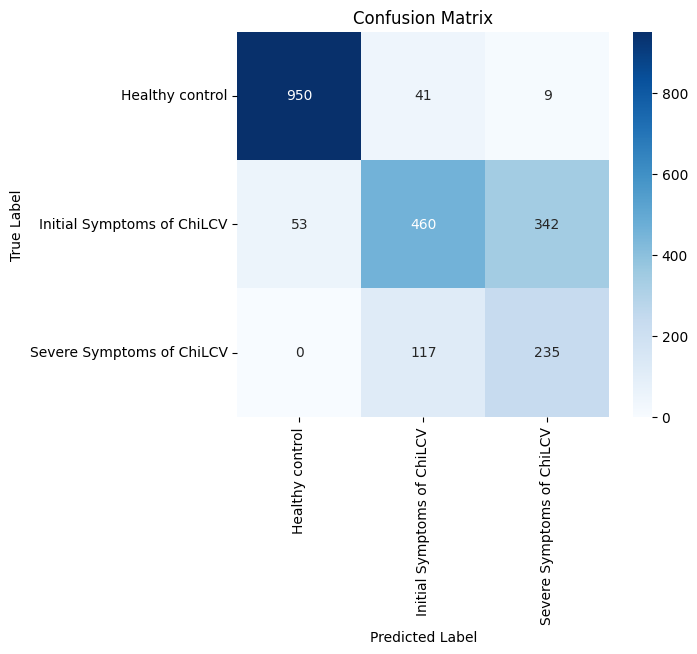

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=test_gen.class_indices.keys(),
            yticklabels=test_gen.class_indices.keys())

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

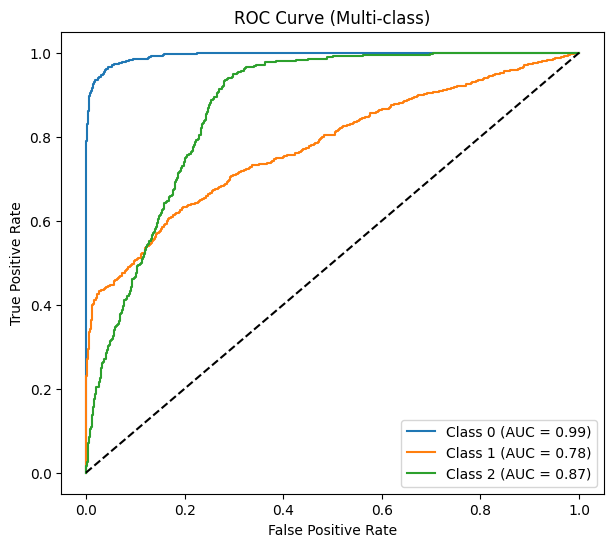

In [29]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

n_classes = len(test_gen.class_indices)

y_true_bin = label_binarize(y_true, classes=range(n_classes))
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(7,6))

for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--')  # diagonal line

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Multi-class)')
plt.legend()
plt.show()


In [35]:
combined_history = {
    'accuracy': history1.history['accuracy'] + history2.history['accuracy'],
    'val_accuracy': history1.history['val_accuracy'] + history2.history['val_accuracy'],
    'loss': history1.history['loss'] + history2.history['loss'],
    'val_loss': history1.history['val_loss'] + history2.history['val_loss']
}

In [36]:
import pickle

with open(r"D:\Chilli final dataset\mobilenetv2training_history.pkl", "wb") as f:
    pickle.dump(combined_history, f)

In [37]:
with open(r"D:\Chilli final dataset\mobilenetv2training_history.pkl", "rb") as f:
    history = pickle.load(f)

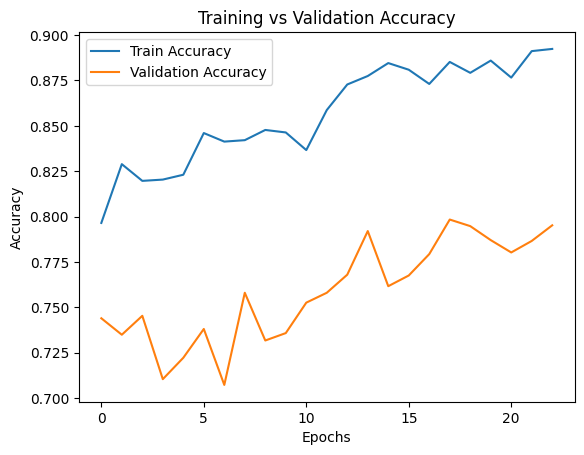

In [38]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(history['accuracy'], label='Train Accuracy')
plt.plot(history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training vs Validation Accuracy')
plt.show()

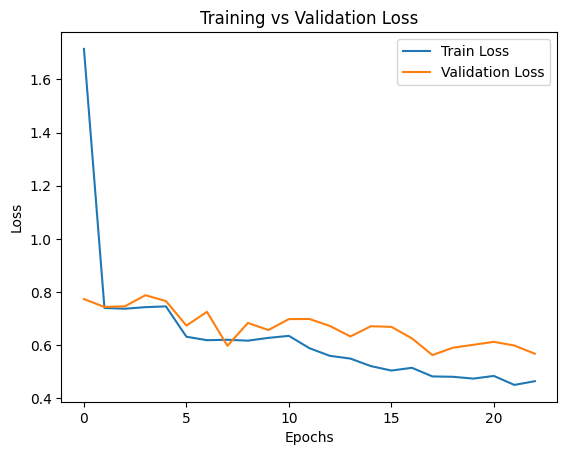

In [39]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(history['loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training vs Validation Loss')
plt.show()

In [ ]:
import cv2
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

def get_last_conv_layer(model):
    for layer in reversed(model.layers):
        if isinstance(layer, tf.keras.layers.Conv2D):
            return layer.name

def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        class_idx = tf.argmax(predictions[0])
        loss = predictions[:, class_idx]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

# -------------------------------
# TEST IMAGE PATH
# -------------------------------
img_path = r"D:\Chilli final dataset\test\Healthy\sample.jpg"

img = tf.keras.preprocessing.image.load_img(img_path, target_size=(224,224))
img_array = tf.keras.preprocessing.image.img_to_array(img)
img_array = np.expand_dims(img_array/255.0, axis=0)

last_conv_layer = get_last_conv_layer(model)

heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer)

# -------------------------------
# SUPERIMPOSE HEATMAP
# -------------------------------
img = cv2.imread(img_path)
img = cv2.resize(img, (224,224))

heatmap = cv2.resize(heatmap, (224,224))
heatmap = np.uint8(255 * heatmap)
heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

superimposed_img = heatmap * 0.4 + img

plt.figure()
plt.imshow(cv2.cvtColor(superimposed_img.astype('uint8'), cv2.COLOR_BGR2RGB))
plt.title("Grad-CAM")
plt.axis('off')
plt.show()